In [1]:
# Import required packages
# import os
# import sys
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
# from datetime import datetime, timedelta
# import time
# import rasterio as rio
# import xarray as xr
# import rioxarray
# import logging
# root_logger = logging.getLogger()
# root_logger.setLevel('WARNING')
# import logging
# from imageMath import IML
# import subprocess
# from scipy.interpolate import interpn

In [2]:
reference_fn = f'./slcs/S1_023790_IW1_20170123T121346_VV_98AA-BURST.tiff'
secondary_fn = f'./slcs/S1_023790_IW1_20230128T121423_VV_8B97-BURST.tiff'

ds1 = gdal.Open(reference_fn, gdal.GA_ReadOnly)
slc1 = ds1.GetRasterBand(1).ReadAsArray()

ds2 = gdal.Open(secondary_fn, gdal.GA_ReadOnly)
slc2 = ds2.GetRasterBand(1).ReadAsArray()

I1 = np.abs(slc1)
I2 = np.abs(slc2)

/mnt/Backups/gbrench/sw/miniconda3/envs/mintpy/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [89]:
I1_crop = np.flip(I1[290:420, 15100:15450], 0)
I2_crop = np.flip(I2[290:420, 15265:15615], 0)

In [26]:
I1_crop.shape

(1496, 8000)

In [59]:
np.quantile(I1_crop, 0.02)

12.041595458984375

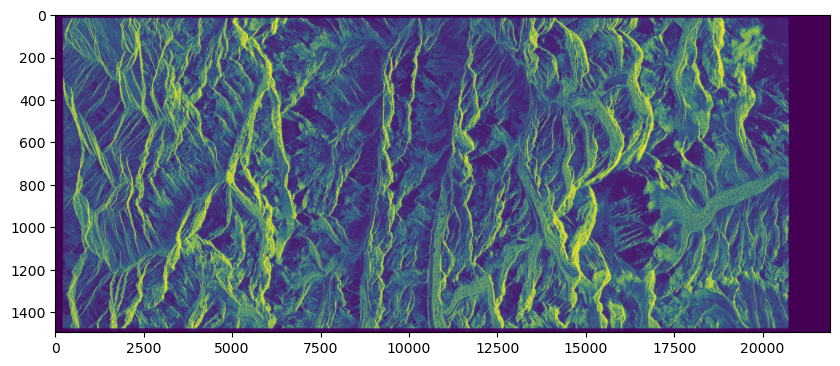

In [64]:
f, ax = plt.subplots(figsize=(10, 10))
ax.imshow(I2, vmin=0, vmax=300)
ax.set_aspect(6)

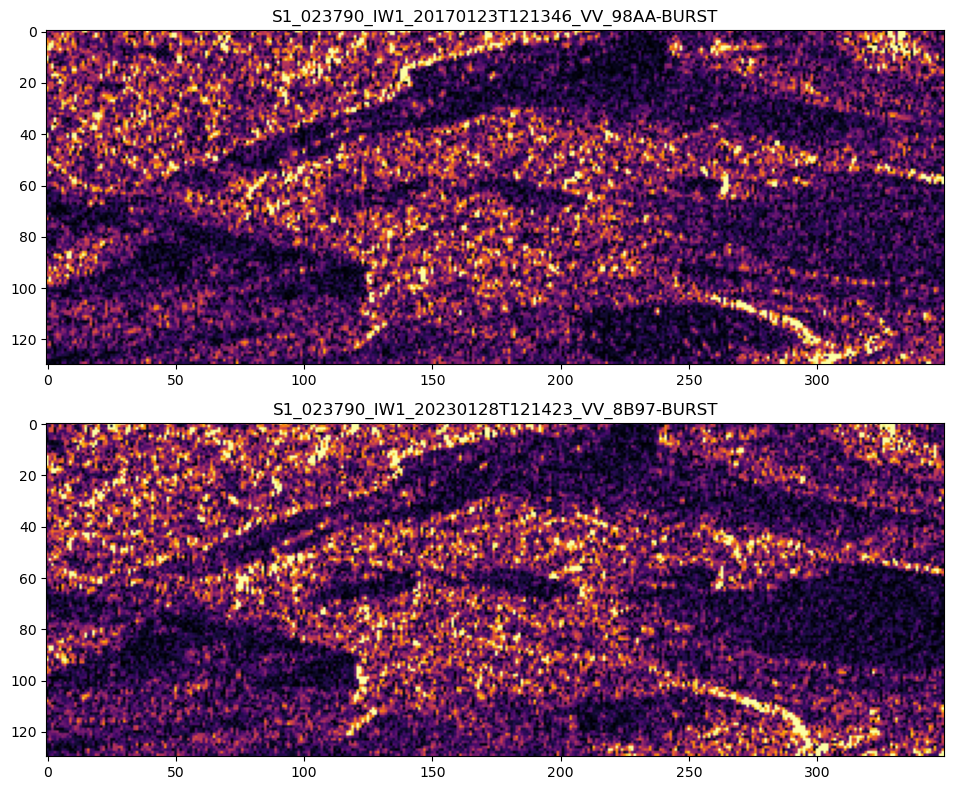

In [95]:
f, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].imshow(I1_crop, vmin=12, vmax=360, cmap='inferno')
ax[0].set_title('S1_023790_IW1_20170123T121346_VV_98AA-BURST')
#ax[0].set_aspect(6)
ax[1].imshow(I2_crop, vmin=12, vmax=360, cmap='inferno')
ax[1].set_title('S1_023790_IW1_20230128T121423_VV_8B97-BURST')
#ax[1].set_aspect(6)
plt.tight_layout()